In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler,  LabelEncoder
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
print("Environment setup complete.")

Environment setup complete.


# Loading the dataset and dataset information


In [3]:


try:
    # 1. Define the full path to the CSV file.
    file_path = '/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv'
    # 2. Use pandas to read the CSV file into a DataFrame.
    df = pd.read_csv(file_path) 
    print('Dataset loaded successfully.')
    
    # Rest of the successful code block
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    print("\nDisplay dataset information:")
    print(df.info())
    print("\nDescriptive Statistics:")
    print(df.describe())

except FileNotFoundError:
    print(f"Error: credit_risk_dataset.csv not found at {file_path}")
    # You might want to keep the exit() but it's often better to let a notebook continue
    # exit() 
except Exception as e:
    print(f"An unexpected error occurred during loading or processing: {e}")

Dataset loaded successfully.

First 5 rows of the dataset:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.

# Step 1: Scatter plots
(Coloured by loan status)

1.   Age vs. Income:Essentially, as a person's income and age increase, the likelihood of them failing to repay the loan decreases.
2.   Loan Amount vs. Interest Rate: The higher the loan interest rate and the higher the loan amount, the greater the chance of them not repaying the loan.
3.  Loan Percentage of Income vs. Income:The higher the income and the lower the loan percentage, the lesser the chance of not repaying the loan.
4.  Employment Length vs. Age: The higher the age and the longer the employment length, the lower the chance of not repaying the loan










--- Step 1:Generating scatter plots


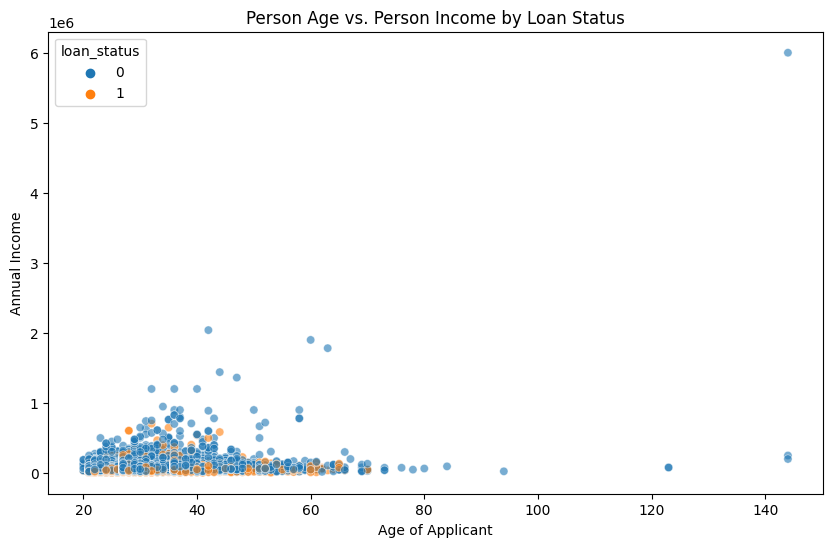

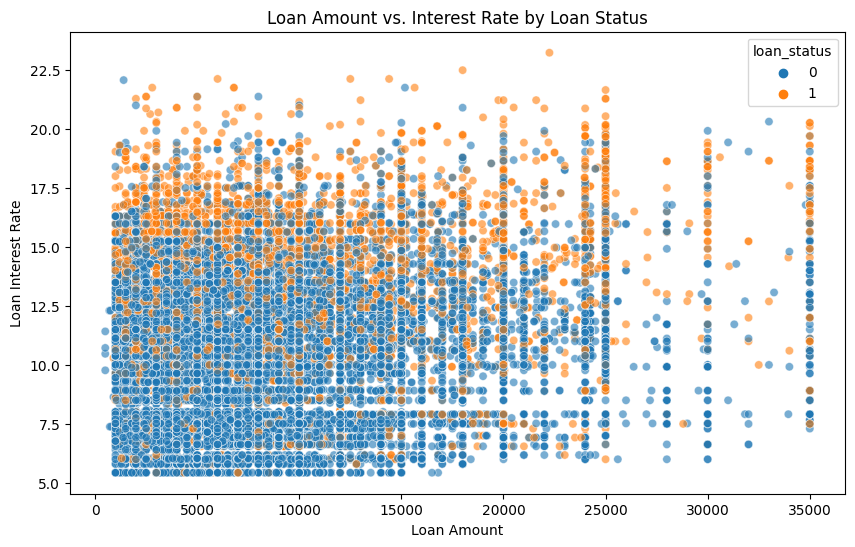

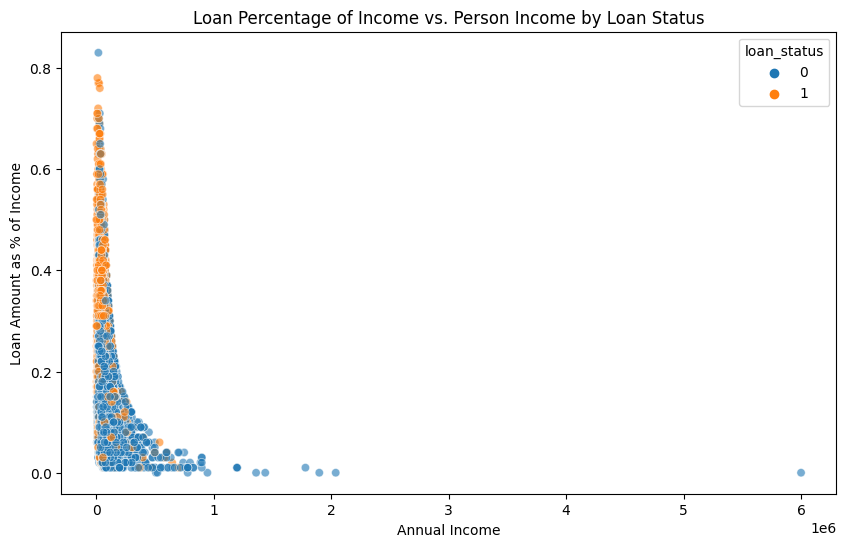

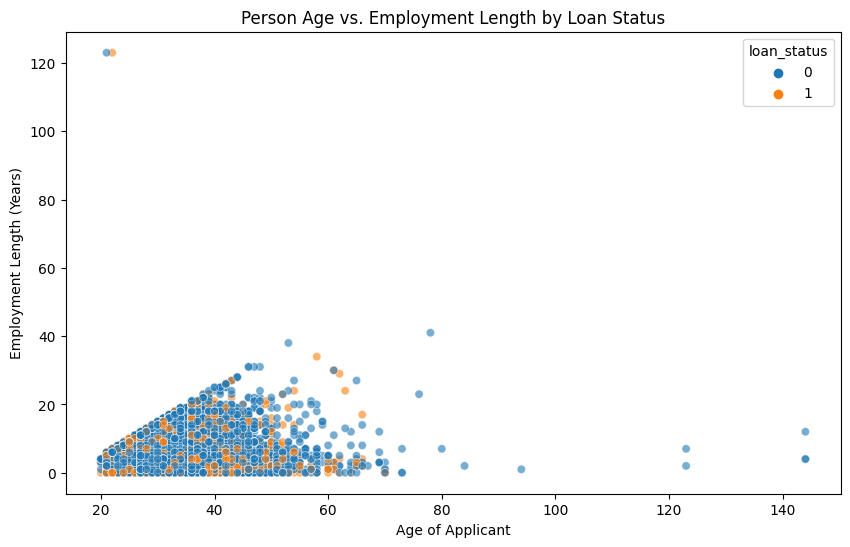

In [4]:
# Scatter plots
print("\n--- Step 1:Generating scatter plots")
# 1. Age vs. Income, colored by Loan Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='person_age', y='person_income', hue='loan_status', alpha=0.6)
plt.title('Person Age vs. Person Income by Loan Status')
plt.xlabel('Age of Applicant')
plt.ylabel('Annual Income')
plt.show()
# 2. Loan Amount vs. Interest Rate, colored by Loan Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='loan_amnt', y='loan_int_rate', hue='loan_status', alpha=0.6)
plt.title('Loan Amount vs. Interest Rate by Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Loan Interest Rate')
plt.show()
# 3. Loan Percentage of Income vs. Income, colored by Loan Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='person_income', y='loan_percent_income', hue='loan_status', alpha=0.6)
plt.title('Loan Percentage of Income vs. Person Income by Loan Status')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount as % of Income')
plt.show()
# 4. Employment Length vs. Age, colored by Loan Status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='person_age', y='person_emp_length', hue='loan_status', alpha=0.6)
plt.title('Person Age vs. Employment Length by Loan Status')
plt.xlabel('Age of Applicant')
plt.ylabel('Employment Length (Years)')
plt.show()

# STEP 2: Handling missing values


1.   Identifying missing values
2.  Addressing obvious errors
3.   Creating columns to impute



In [5]:
print("\n--- Step 2: Handling Missing Values ---")

#1
#identifying missing values
print("\nMissing values before imputation:")
print(df.isnull().sum())

#2
# Addressing obvious errors in 'person_age' and 'person_emp_length' by converting them to NaN
# Max realistic age is around 100
df.loc[df['person_age'] > 100, 'person_age'] = np.nan # [1]
# Max realistic employment length is typically less than 70 years.
df.loc[df['person_emp_length'] > 70, 'person_emp_length'] = np.nan # [1]
# Employment length cannot be greater than age
df.loc[df['person_emp_length'] > df['person_age'], 'person_emp_length'] = np.nan
print("Addressed obvious errors in 'person_age' and 'person_emp_length' by converting them to NaN.")

#3
# The list of columns to impute
numerical_cols_to_impute = ['loan_int_rate', 'person_emp_length', 'person_age']
# Create missing indicator columns before imputation
for col in numerical_cols_to_impute:
    if df[col].isnull().any():
        df[f'{col}_missing'] = df[col].isnull().astype(int)
        print(f"Created missing indicator for '{col}': '{col}_missing'")

#4
#Median imputation for numerical features
imputer_median = SimpleImputer(strategy='median')
# Apply median imputation to the identified numerical columns
df[numerical_cols_to_impute] = imputer_median.fit_transform(df[numerical_cols_to_impute])
print(f"Median imputed missing values in {numerical_cols_to_impute}.")
# Re-check for missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())


--- Step 2: Handling Missing Values ---

Missing values before imputation:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Addressed obvious errors in 'person_age' and 'person_emp_length' by converting them to NaN.
Created missing indicator for 'loan_int_rate': 'loan_int_rate_missing'
Created missing indicator for 'person_emp_length': 'person_emp_length_missing'
Created missing indicator for 'person_age': 'person_age_missing'
Median imputed missing values in ['loan_int_rate', 'person_emp_length', 'person_age'].

Missing values after imputation:
person_age                    0
person_income                 0

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


# STEP 3:  Outlier Detection and Treatment




In [6]:
print("\n--- Step 3: Outlier Detection and Treatment ---")

# Numerical features for outlier treatment (excluding binary/categorical-like numerical)
numerical_features_for_outliers = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate',
    'loan_percent_income', 'cb_person_cred_hist_length']

# Apply IQR-based Winsorization for treatment
print("Applying IQR-based Winsorization for outlier treatment")
for col in numerical_features_for_outliers:
    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds for outliers (1.5 * IQR rule)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Winsorize: replace values outside bounds with the bounds themselves
    # Using np.where for direct capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Winsorized outliers in '{col}'.")

# Apply Log Transformation to highly skewed features (e.g., income, loan_amnt) [2]
# Add a small constant (1) to avoid log(0) if necessary (np.log1p does this automatically)
df['person_income_log'] = np.log1p(df['person_income'])
df['loan_amnt_log'] = np.log1p(df['loan_amnt'])
print("Log transformation applied to 'person_income' and 'loan_amnt'.")


--- Step 3: Outlier Detection and Treatment ---
Applying IQR-based Winsorization for outlier treatment
Winsorized outliers in 'person_age'.
Winsorized outliers in 'person_income'.
Winsorized outliers in 'loan_amnt'.
Winsorized outliers in 'loan_int_rate'.
Winsorized outliers in 'loan_percent_income'.
Winsorized outliers in 'cb_person_cred_hist_length'.
Log transformation applied to 'person_income' and 'loan_amnt'.


# STEP 4 : Selection of 4 models


1.   Logistic Regression Classifier
2.   Random Forest Classifier
3.   XGBoost Classifier
4.   KNN Classifier



In [7]:
print("\n--- Step 4A: Data Preparation for Modeling ---")



# 1. Encode categorical variables
print("Encoding categorical variables...")

# Create label encoders for categorical features
label_encoders = {}
categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for feature in categorical_features:
    le = LabelEncoder()
    df[feature + '_encoded'] = le.fit_transform(df[feature])
    label_encoders[feature] = le
    print(f"Encoded '{feature}' -> '{feature}_encoded'")

# 2. Select features for modeling
print("\nSelecting features for modeling...")

# Use both original and transformed features
feature_columns = [
    'person_age', 'person_income', 'person_income_log', 'person_emp_length',
    'loan_amnt', 'loan_amnt_log', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'person_home_ownership_encoded',
    'loan_intent_encoded', 'loan_grade_encoded', 'cb_person_default_on_file_encoded'
]

X = df[feature_columns]
y = df['loan_status']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features selected: {feature_columns}")

# 3. Split data into training and testing sets
print("\nSplitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts()}")

# 4. Scale features for models that need it (Logistic Regression and KNN)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")



--- Step 4A: Data Preparation for Modeling ---
Encoding categorical variables...
Encoded 'person_home_ownership' -> 'person_home_ownership_encoded'
Encoded 'loan_intent' -> 'loan_intent_encoded'
Encoded 'loan_grade' -> 'loan_grade_encoded'
Encoded 'cb_person_default_on_file' -> 'cb_person_default_on_file_encoded'

Selecting features for modeling...
Feature matrix shape: (32581, 13)
Target variable shape: (32581,)
Features selected: ['person_age', 'person_income', 'person_income_log', 'person_emp_length', 'loan_amnt', 'loan_amnt_log', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_encoded', 'loan_intent_encoded', 'loan_grade_encoded', 'cb_person_default_on_file_encoded']

Splitting data into train and test sets...
Training set size: 26064 samples
Testing set size: 6517 samples
Training set class distribution:
loan_status
0    20378
1     5686
Name: count, dtype: int64

Scaling features...
Feature scaling completed.


In [14]:
print("\n--- Step 4B: Model Implementation and Training ---")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store results
model_results = {}

print("Training models...")
print("=" * 60)

# Train and evaluate each model
for name, model in models.items():
    print(f"\n Training {name}...")
    
    # Use scaled data for Logistic Regression and KNN, original data for tree-based models
    if name in ['Logistic Regression', 'KNN']:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test
    
    # Train the model
    model.fit(X_train_use, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_use)
    y_pred_proba = model.predict_proba(X_test_use)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else "N/A"
    
    # Store results
    model_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f" {name} trained successfully!")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   ROC-AUC: {roc_auc:.4f}" if roc_auc != "N/A" else f"   ROC-AUC: {roc_auc}")

print(f"\n All {len(models)} models trained successfully!")



--- Step 4B: Model Implementation and Training ---
Training models...

 Training Logistic Regression...
 Logistic Regression trained successfully!
   Accuracy: 0.8467
   ROC-AUC: 0.8580

 Training Random Forest...
 Random Forest trained successfully!
   Accuracy: 0.9299
   ROC-AUC: 0.9314

 Training XGBoost...
 XGBoost trained successfully!
   Accuracy: 0.9359
   ROC-AUC: 0.9507

 Training KNN...
 KNN trained successfully!
   Accuracy: 0.8683
   ROC-AUC: 0.8426

 All 4 models trained successfully!


In [16]:
print("\n--- Step 4C: Model Evaluation and Comparison ---")

# Create comparison DataFrame
import pandas as pd

comparison_data = []
for name, results in model_results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': results['accuracy'],
        'ROC-AUC': results['roc_auc'] if results['roc_auc'] != "N/A" else None
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("MODEL PERFORMANCE COMPARISON:")
print("=" * 50)
print(comparison_df.to_string(index=False, float_format='%.4f'))

# Identify best performing model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f"\n BEST PERFORMING MODEL: {best_model_name}")
print(f"   Best Accuracy: {best_accuracy:.4f}")




--- Step 4C: Model Evaluation and Comparison ---
MODEL PERFORMANCE COMPARISON:
              Model  Accuracy  ROC-AUC
            XGBoost    0.9359   0.9507
      Random Forest    0.9299   0.9314
                KNN    0.8683   0.8426
Logistic Regression    0.8467   0.8580

 BEST PERFORMING MODEL: XGBoost
   Best Accuracy: 0.9359



--- Step 4D: Confusion Matrices and Visualizations ---


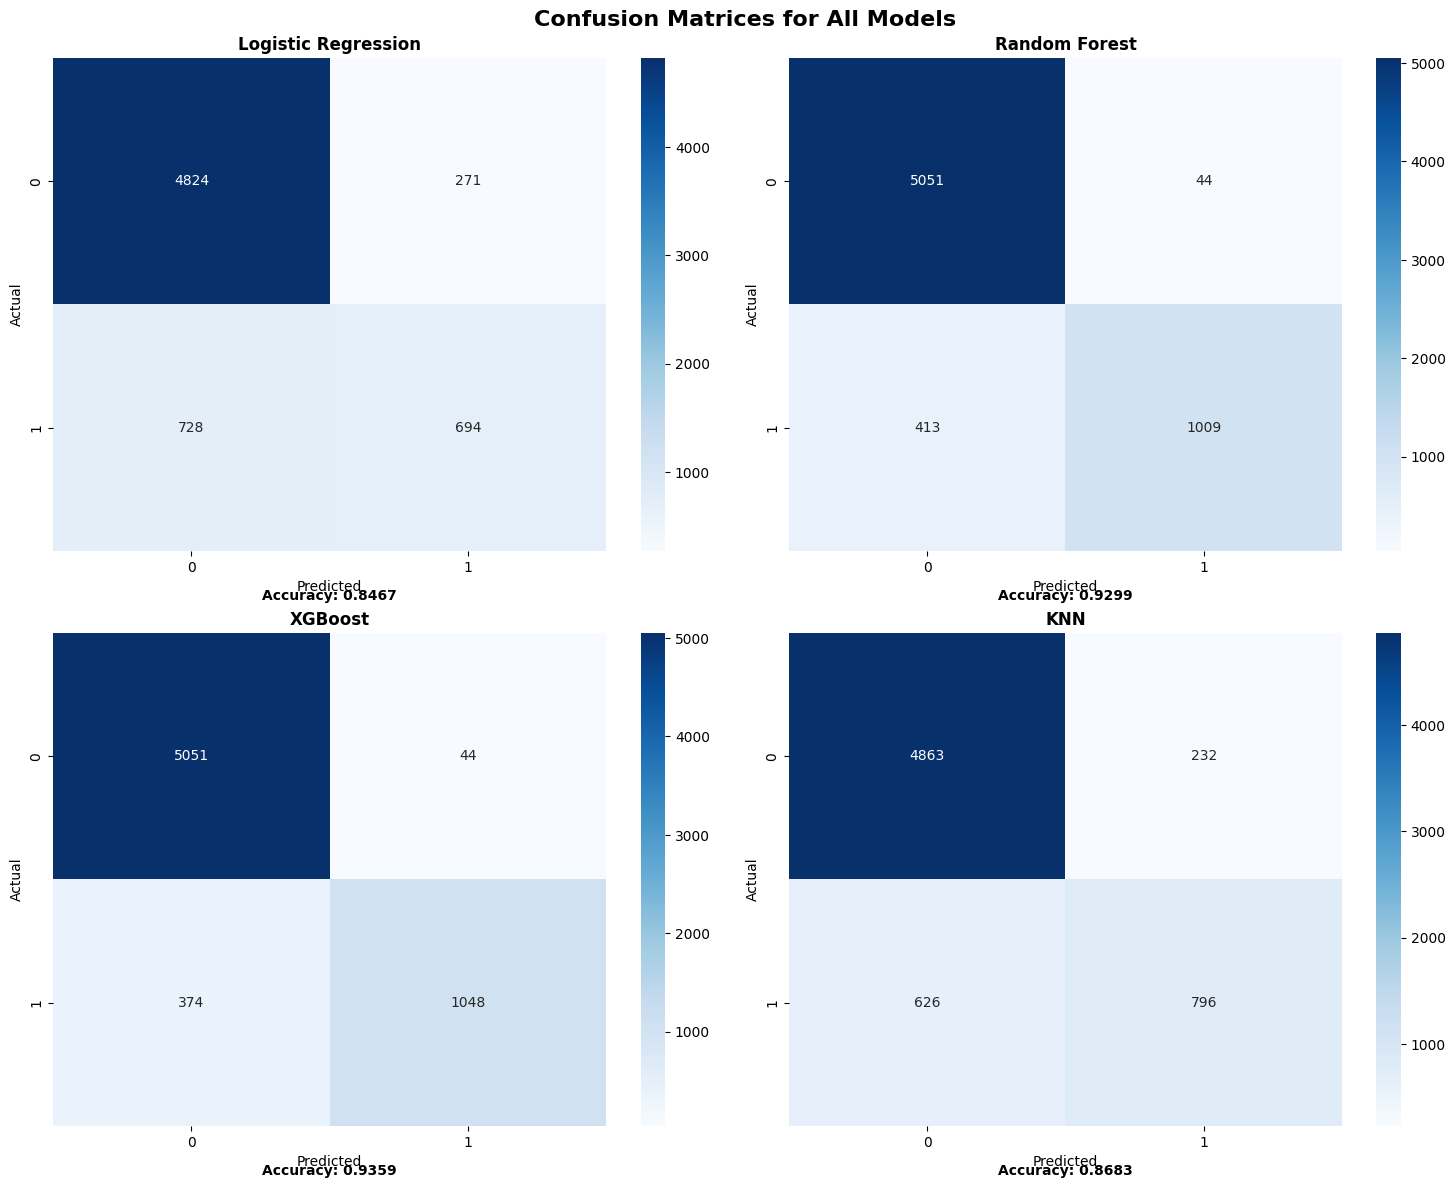

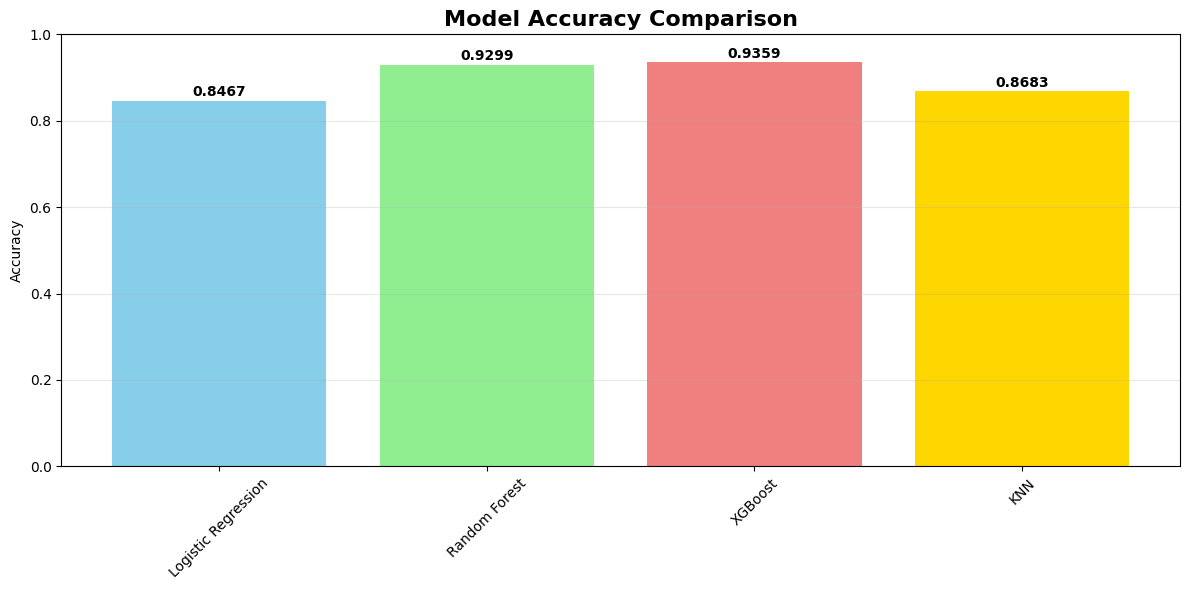

In [11]:
print("\n--- Step 4D: Confusion Matrices and Visualizations ---")

# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

axes = axes.ravel()

for idx, (name, results) in enumerate(model_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    
    # Add accuracy to subplot
    accuracy = results['accuracy']
    axes[idx].text(0.5, -0.1, f'Accuracy: {accuracy:.4f}', 
                   transform=axes[idx].transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Performance comparison bar chart
plt.figure(figsize=(12, 6))
models_names = list(model_results.keys())
accuracies = [model_results[name]['accuracy'] for name in models_names]

bars = plt.bar(models_names, accuracies, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
